### Remapping IllustrisTNG boxes

This notebook is a sample to understand the IllustrisTNG outputs relavant for this project.

Author: Soumya Shreeram

Date: 27th Jan 2023

Contact: shreeramsoumya at gmail dot com


In [ ]:
import numpy as np
import os
import pandas as pd

# plotting imports
import matplotlib as mpl
import matplotlib.pyplot as plt

# other imports
from astropy.cosmology import Planck18 as cosmo
from astropy.constants import c
from astropy import units as u

In [2]:
mpl.rcParams['agg.path.chunksize'] = 100000
%matplotlib inline
font = {'family' : "Latin Modern Roman",
'weight' : 'medium',
'size'   : 18}
mpl.rc('font', **font)

In [3]:
%load_ext autoreload
%autoreload 2

In [ ]:
os.chdir(f"{os.getcwd()}/../src/")

from remap_IllustrisTNG import Lightcone_IllustrisTNG
from tools import plotting as pt
plt.rcParams['font.family'] = 'sans-serif'

Let's begin with plotting a snapshot of a 'subhalo' particles, within the TNG group catalog.

For this to work in your `sim_data_dir` filepath, you need to have the TNG group catalog files: 

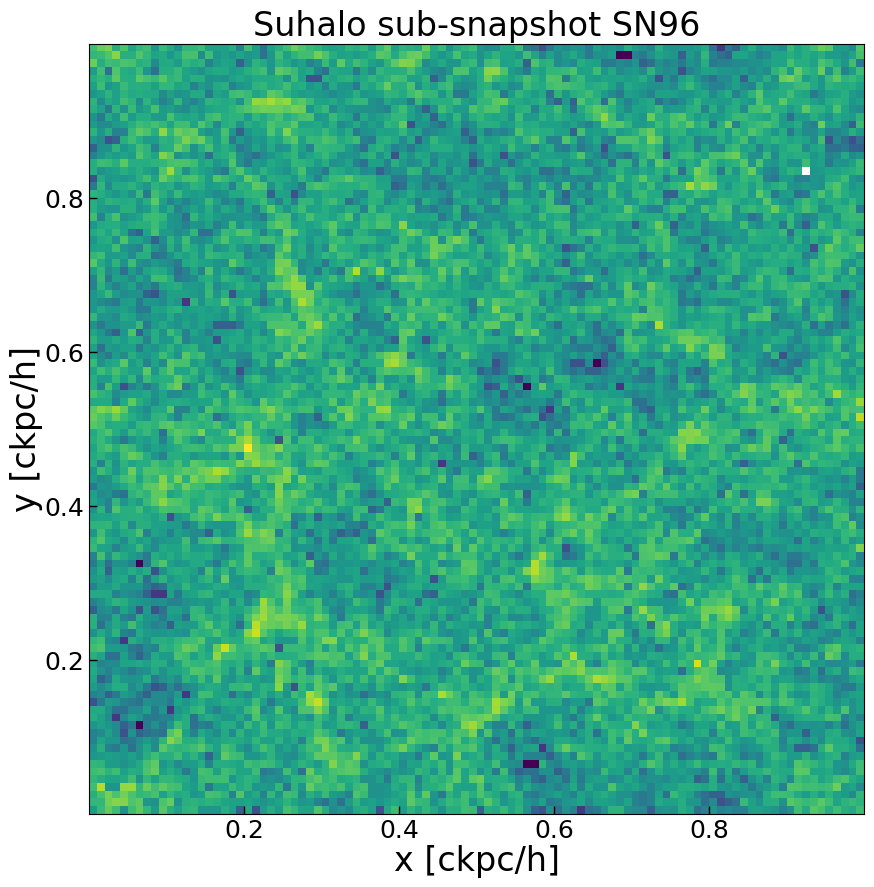

In [ ]:
sim_data_dir = 'your/path/to/TNG/data/products'
base_working_dir = 'your/base/working/dir'
out_data_dir = 'path/to/dir/where/you/want/to/save/stuff'
lightcone_subhalo = Lightcone_IllustrisTNG(particle_type = 'Subhalo', snap_nr='96',
                                           sim_data_dir=sim_data_dir,
                                           base_working_dir=base_working_dir,
                                           out_data_dir=out_data_dir)

pos = lightcone_subhalo.get_particles_coord(plot_particles=True)

create the file that has the lightcone information for every subshell

In [19]:
lightcone_subhalo.get_lightcone_shell_boundaries()
f = pd.read_csv(lightcone_subhalo.snapshot_info_file, sep=' ')
f.columns            

Index(['Unnamed: 0', 'snapshot', 'redshift', 'd_c', 'd_c_min', 'd_c_max',
       'redshift_min', 'redshift_max', 'volMpc3'],
      dtype='object')

Let's briefly figure out the units of the axes.

In [6]:
h = cosmo.H0/100
light_c = c*(u.km/u.s)
1/h

<Quantity 1.47797813 Mpc s / km>

Or the complete 3D projection of the coordinates

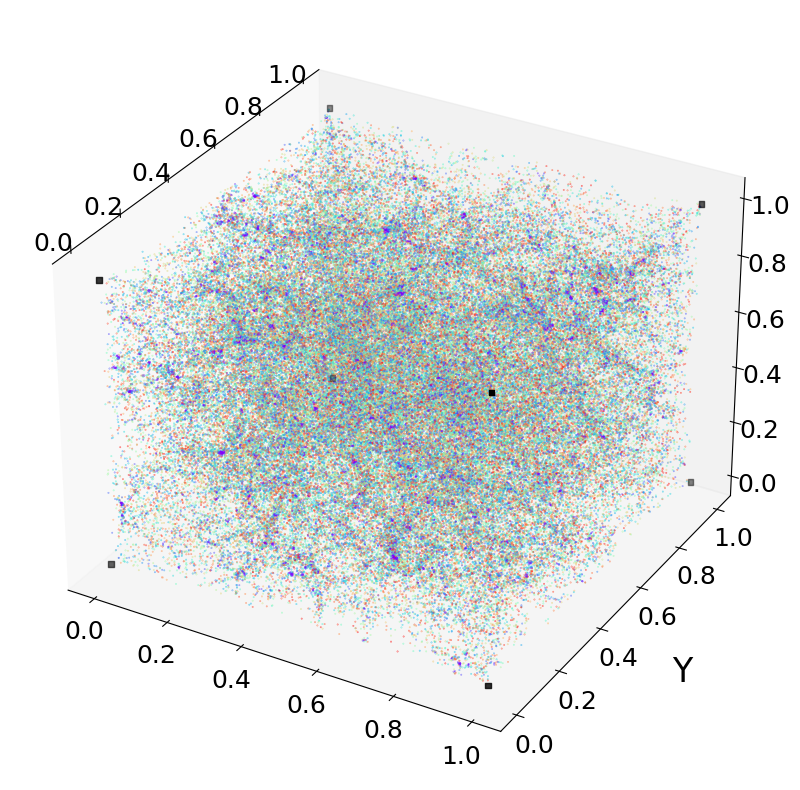

In [12]:
plotname = f"{lightcone_subhalo.particle_type}_SN{lightcone_subhalo.snap_nr}_test.png"
ax, fig = pt.plot_3D(pos, plot_path = lightcone_subhalo.save_plots_dir, 
                     plotname = plotname)

edges = cgm.util.get_edges(pos)
ax.scatter3D(edges[:, 0], edges[:, 1], edges[:, 2], marker='s', c='k', s=15)

We now check out the outputs of boxremap in the x-y prjection with a sample rate of 1/1000 particles to fasten the computation.

In [13]:
Lx, Ly, Lz = 4.1231, 0.7276, 0.3333

lightcone_subhalo.do_boxremap(Lx, Ly, Lz, clobber=False, bins=180)

INFO:Lightcone_IllustrisTNG:Got original positions
INFO:Lightcone_IllustrisTNG:transforming coordinates now 


Let's load the remapped coordinated and view them in 3D

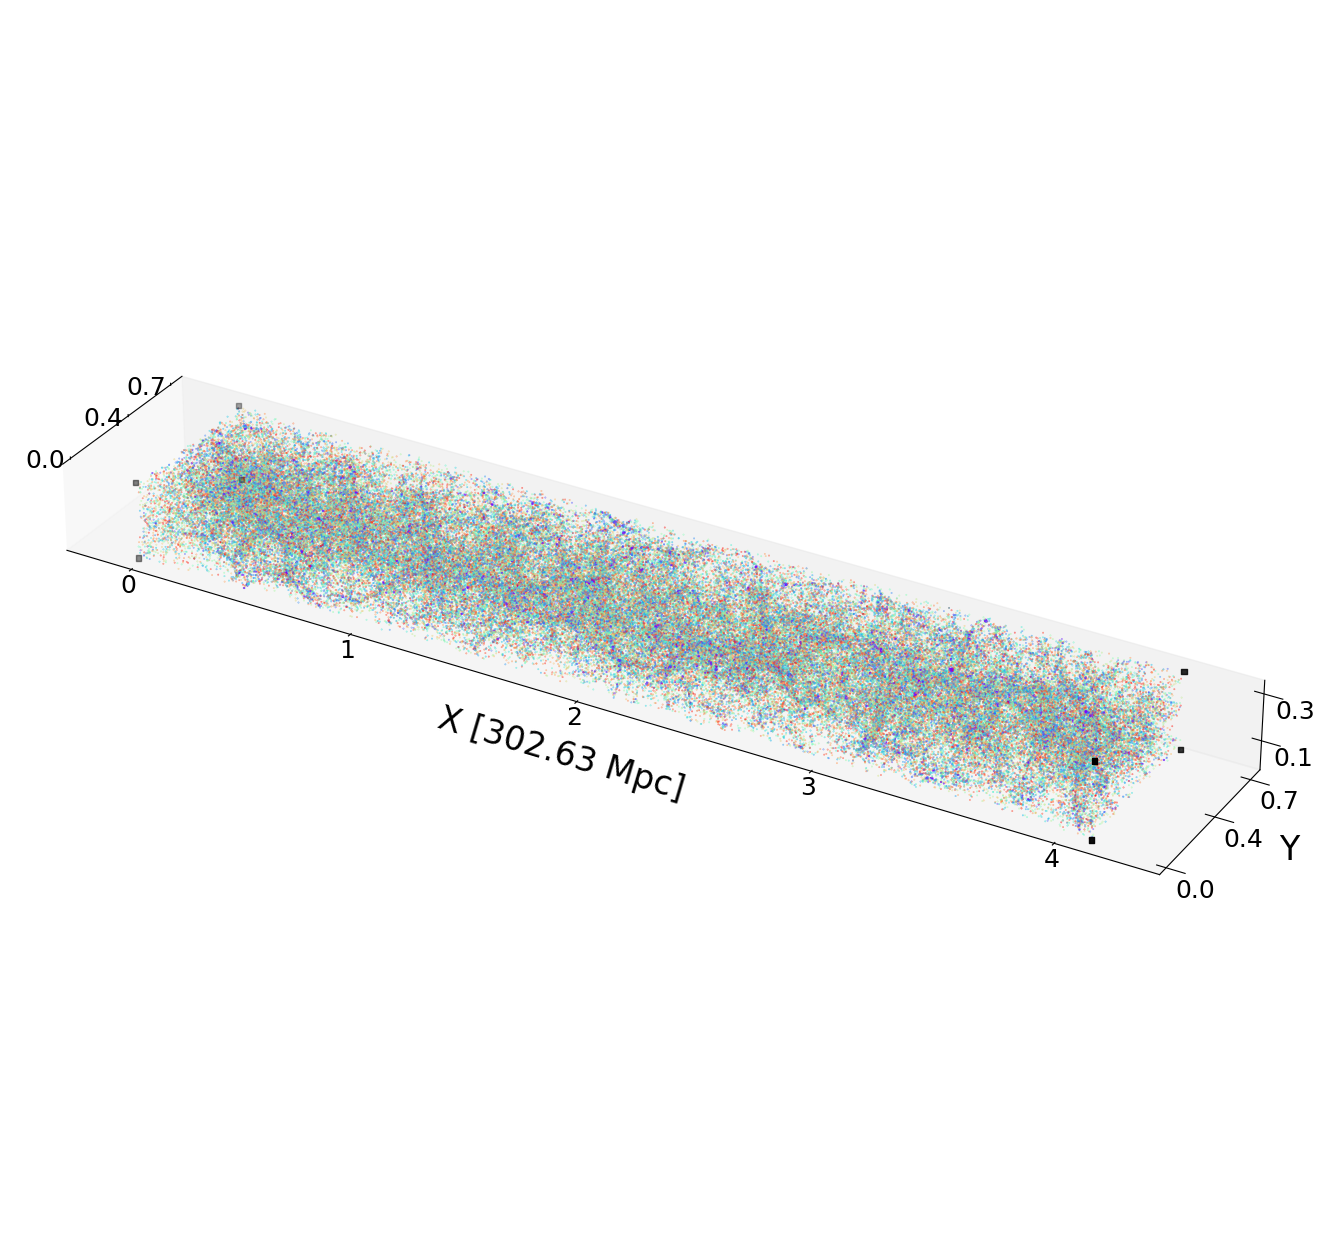

In [16]:
remapped_coords = np.load(lightcone_subhalo.remapped_coords, allow_pickle=True)
ax, fig = pt.plot_3D(remapped_coords, plot_path = lightcone_subhalo.save_plots_dir,
                     plotname=plotname,
                     figsize = (16, 25))

# plot the edges estimated by simply getting the min/max in (x, y, z)
edges_re = cgm.util.get_edges(remapped_coords)
ax.scatter3D(edges_re[:, 0], edges_re[:, 1], edges_re[:, 2], marker='s', c='k', s=15)

pt.set_labels(ax, f'X [{lightcone_subhalo.boxsize:.2f}]', 'Y', labelpad=[100, 10, 1])
ax.set_yticks([0, np.round(Ly/2, 1), np.round(Ly, 1)])
ax.set_zticks([np.round(Lz/3, 1), np.round(Lz, 1)])

ax.set_zlabel('Z' )
ax.set_box_aspect((Lx, Ly, Lz))


In [17]:
print(f"Percentage of remapped particles: {(remapped_coords.shape[0]/pos.shape[0])*100:.2f} %")

edges_re[edges_re<1e-3] = 0
edges_re

Percentage of remapped particles: 100.00 %


array([[0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.33333325],
       [0.        , 0.72760688, 0.        ],
       [0.        , 0.72760688, 0.33333325],
       [4.12310537, 0.        , 0.        ],
       [4.12310537, 0.        , 0.33333325],
       [4.12310537, 0.72760688, 0.        ],
       [4.12310537, 0.72760688, 0.33333325]])

Saved the observer location in the `out_data_dir` you feed your `Lightcone_IllustrisTNG` class.

In [27]:
np.save(f"{lightcone_subhalo.out_data_dir}/observer_location_Lx{Lx:.2f}_Ly{Ly:.2f}_Lz{Lz:.2f}.npy", edges_re, allow_pickle=True)

Now that we have the observer locations, we redo the remapping with all the concerned snapshots upto $z$ of your preference. Once we do this, we can construct the lightcone.